# 02 — Earth System × Metabolite Correlation

**Question:** Do climate, geology, and geography predict metabolite profiles in regional food systems?

**Approach:**
1. Aggregate food-level metabolite matrix to RSU level (mean across staple foods)
2. Build RSU environmental feature matrix (climate + geology + coordinates)
3. Correlation heatmap: env features × metabolite dims
4. RSU PCA in metabolite space, colored by environmental gradients

**v0.2 constraint:** 12 RSUs — treat as exploratory pattern detection, not statistical inference.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from pathlib import Path
from rsu_loader import load_all_rsus

# Macro dims recapitulate food category — exclude from geographic analysis
MACRO_DIMS = [
    'primary_metabolites.protein_content',
    'primary_metabolites.lipid_content',
    'primary_metabolites.starch_content',
]

## Build RSU-level matrices

In [2]:
rsus = load_all_rsus()

# Environmental feature matrix — one row per RSU
env_rows = []
for r in rsus:
    env_rows.append({
        'region_id': r.region_id,
        'name': r.name,
        'lat': r.coordinates.lat,
        'lon': r.coordinates.lon,
        'altitude_m': getattr(r.coordinates, 'altitude_m', None),
        'temp_mean': r.climate.temperature_mean,
        'temp_seasonality': r.climate.temperature_seasonality,
        'precip_mean': r.climate.precipitation_mean,
        'precip_seasonality': r.climate.precipitation_seasonality,
        'soil_pH': r.geology.soil_pH,
        'geology': r.geology.parent_material,
        'fermentation_prevalence': r.food_system.fermentation_prevalence,
        'industrial_processing': r.culture.industrial_processing_index,
    })

env_df = pd.DataFrame(env_rows).set_index('region_id')
print("Environmental features:")
print(env_df[['name', 'altitude_m', 'temp_mean', 'precip_mean', 'soil_pH', 'geology']].to_string())

Environmental features:
                                                               name  altitude_m  temp_mean  precip_mean  soil_pH       geology
region_id                                                                                                                     
RSU-01                                               Boreal Finland         150        2.5          600      4.8   metamorphic
RSU-02                                                Boreal Canada         400        1.5          500      5.0   metamorphic
RSU-03                                               Siberian Taiga         200       -5.0          400      5.5   sedimentary
RSU-04                                      Atlantic Western Europe         100       12.0          750      7.2   sedimentary
RSU-05                                               Central Europe         200        9.0          650      6.5   sedimentary
RSU-06                                         East Asian Temperate          50       1

In [3]:
# Build category map from RSU objects
# Aromatics are measured as dry-weight spice concentrations — sumac at 8-15 g/100g malic acid
# is 20-30x higher than apple at 0.22-0.53 g/100g. Including aromatics in RSU-level means
# makes spice chemistry dominate the PCA axes, not geographic food system signals.
EXCLUDE_CATEGORIES = {'aromatic'}

category_map = {}
for r in rsus:
    for food in r.staple_foods:
        category_map[(r.region_id, food.name)] = food.macronutrient_category

food_matrix = pd.read_csv('../data/metabolites/rsu_metabolite_matrix.csv',
                          index_col=['region_id', 'food_name'])

food_matrix_filtered = food_matrix[
    food_matrix.index.map(lambda idx: category_map.get(idx, '') not in EXCLUDE_CATEGORIES)
]

n_excluded = len(food_matrix) - len(food_matrix_filtered)
print(f"Excluded {n_excluded} aromatic food rows from RSU-level aggregation")

# Geo dims only: exclude macros (protein/fat/carb reflect food category, not geography)
geo_dims = [c for c in food_matrix_filtered.columns if c not in MACRO_DIMS]

rsu_metabolites = food_matrix_filtered[geo_dims].groupby(level='region_id').mean()
print(f"RSU metabolite matrix (geo dims, aromatics excluded): {rsu_metabolites.shape}")
print(f"Geo dims: {geo_dims}")
print()
print(rsu_metabolites.round(3).to_string())

Excluded 39 aromatic food rows from RSU-level aggregation
RSU metabolite matrix (geo dims, aromatics excluded): (45, 30)
Geo dims: ['organic_acids.lactic_acid', 'organic_acids.citric_acid', 'organic_acids.malic_acid', 'primary_metabolites.glucose_concentration', 'key_flavor_bioactives.tannin_content', 'organic_acids.acetic_acid', 'umami_compounds.glutamate', 'terpenes.pinene', 'terpenes.linalool', 'primary_metabolites.fructose_concentration', 'primary_metabolites.ascorbic_acid', 'terpenes.limonene', 'key_flavor_bioactives.capsaicinoids', 'terpenes.myrcene', 'primary_metabolites.oleic_acid', 'primary_metabolites.linoleic_acid', 'key_flavor_bioactives.polyphenol_content', 'key_flavor_bioactives.tocopherol_content', 'key_flavor_bioactives.caffeine_concentration', 'umami_compounds.inosinate', 'key_flavor_bioactives.isothiocyanates', 'umami_compounds.guanylate', 'key_flavor_bioactives.hydroxytyrosol', 'key_flavor_bioactives.theobromine_concentration', 'primary_metabolites.lauric_acid', 'pri

## Correlation: environmental features × metabolite dims

Spearman rank correlation — robust to the non-normal distributions and small N.
Only pairs where both values are non-null across RSUs are used.
Cells with fewer than 4 RSU pairs are left blank (insufficient data).

In [4]:
env_numeric_cols = ['lat', 'altitude_m', 'temp_mean', 'temp_seasonality', 'precip_mean',
                    'precip_seasonality', 'soil_pH', 'fermentation_prevalence',
                    'industrial_processing']

MIN_PAIRS = 4  # minimum RSU pairs to compute a correlation

corr_rows = []
pval_rows = []
n_rows = []

for env_col in env_numeric_cols:
    corr_row = {}
    pval_row = {}
    n_row = {}
    for met_col in geo_dims:
        combined = pd.concat([env_df[env_col], rsu_metabolites[met_col]], axis=1).dropna()
        n = len(combined)
        if n >= MIN_PAIRS:
            rho, pval = spearmanr(combined.iloc[:, 0], combined.iloc[:, 1])
            corr_row[met_col] = round(rho, 3)
            pval_row[met_col] = round(pval, 3)
            n_row[met_col] = n
        else:
            corr_row[met_col] = np.nan
            pval_row[met_col] = np.nan
            n_row[met_col] = n
    corr_rows.append(corr_row)
    pval_rows.append(pval_row)
    n_rows.append(n_row)

corr_df = pd.DataFrame(corr_rows, index=env_numeric_cols)
pval_df = pd.DataFrame(pval_rows, index=env_numeric_cols)
n_df = pd.DataFrame(n_rows, index=env_numeric_cols)

short_names = {c: c.split('.')[-1] for c in geo_dims}
corr_display = corr_df.rename(columns=short_names)

print("Spearman correlations (env feature × metabolite dim):")
print(corr_display.to_string())

Spearman correlations (env feature × metabolite dim):
                         lactic_acid  citric_acid  malic_acid  glucose_concentration  tannin_content  acetic_acid  glutamate  pinene  linalool  fructose_concentration  ascorbic_acid  limonene  capsaicinoids  myrcene  oleic_acid  linoleic_acid  polyphenol_content  tocopherol_content  caffeine_concentration  inosinate  isothiocyanates  guanylate  hydroxytyrosol  theobromine_concentration  lauric_acid  myristic_acid  stearic_acid  palmitic_acid  conjugated_linoleic_acid  palmitoleic_acid
lat                            0.184       -0.200       0.174                  0.117           0.067       -0.095     -0.089     NaN    -0.800                   0.899         -0.200       NaN            NaN      NaN       0.036          0.160              -0.120               0.032                   0.232      0.386              NaN        NaN           1.000                        NaN          NaN            NaN         0.300          0.473           

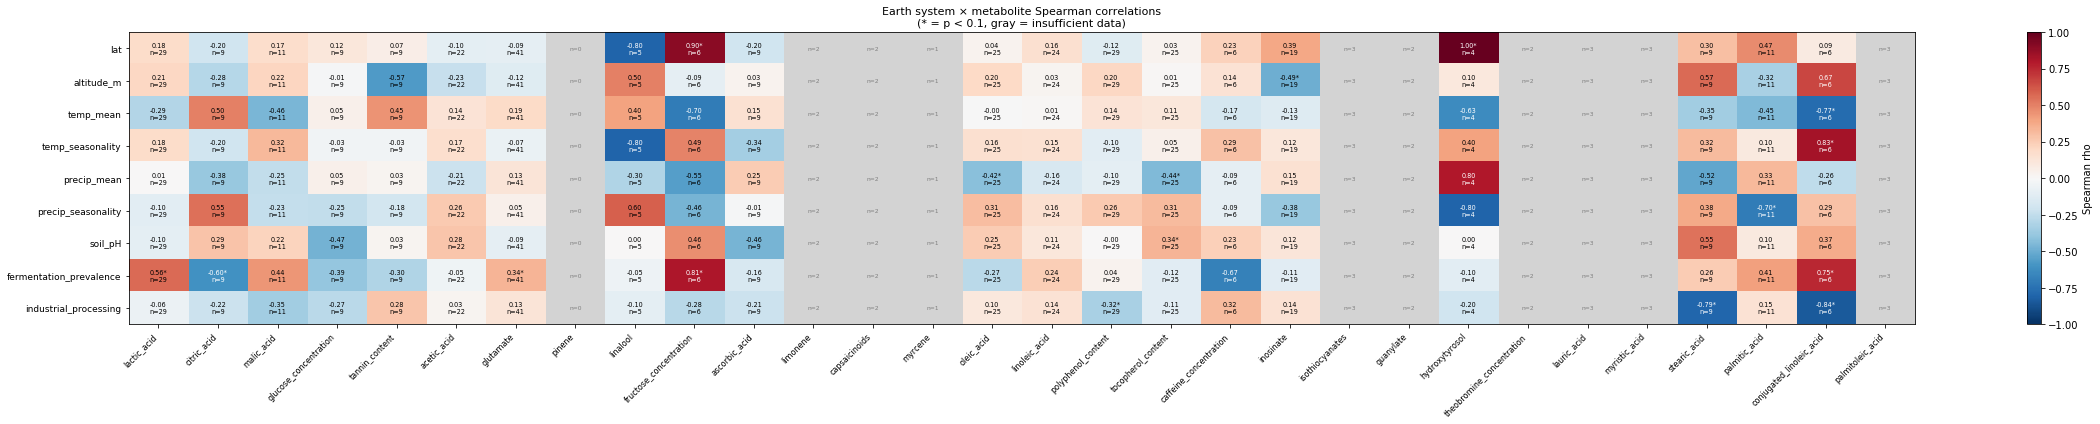

In [5]:
# Heatmap
fig, ax = plt.subplots(figsize=(max(8, len(geo_dims) * 1.1), 6))

data = corr_display.values.astype(float)
cmap = plt.cm.RdBu_r
cmap.set_bad('lightgray')

im = ax.imshow(data, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman rho')

ax.set_xticks(range(len(corr_display.columns)))
ax.set_xticklabels(corr_display.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(env_numeric_cols)))
ax.set_yticklabels(env_numeric_cols, fontsize=9)

# Annotate cells with rho value; mark p < 0.1 with *
for i, env_col in enumerate(env_numeric_cols):
    for j, met_col in enumerate(geo_dims):
        rho = corr_df.iloc[i, j]
        pval = pval_df.iloc[i, j]
        n = n_df.iloc[i, j]
        if not np.isnan(rho):
            star = '*' if pval < 0.1 else ''
            txt = f"{rho:.2f}{star}\nn={n}"
            text_color = 'white' if abs(rho) > 0.6 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=6.5, color=text_color)
        else:
            ax.text(j, i, f'n={n}', ha='center', va='center', fontsize=6, color='gray')

ax.set_title('Earth system × metabolite Spearman correlations\n(* = p < 0.1, gray = insufficient data)', fontsize=11)
plt.tight_layout()
plt.savefig('../data/metabolites/env_metabolite_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## RSU metabolite PCA — colored by environmental gradient

RSUs projected into metabolite space. Color encodes a continuous environmental variable
to visually test whether environmental gradients align with metabolite gradients.

RSUs in PCA: 44
Active dims after dropping all-null columns: 29 of 30
Explained variance: [0.137 0.093 0.089 0.071 0.07  0.068 0.064 0.062 0.05  0.046 0.038 0.037
 0.036 0.027 0.026 0.023 0.014 0.011 0.01  0.008 0.006 0.005 0.003 0.003
 0.002 0.001 0.    0.    0.   ]


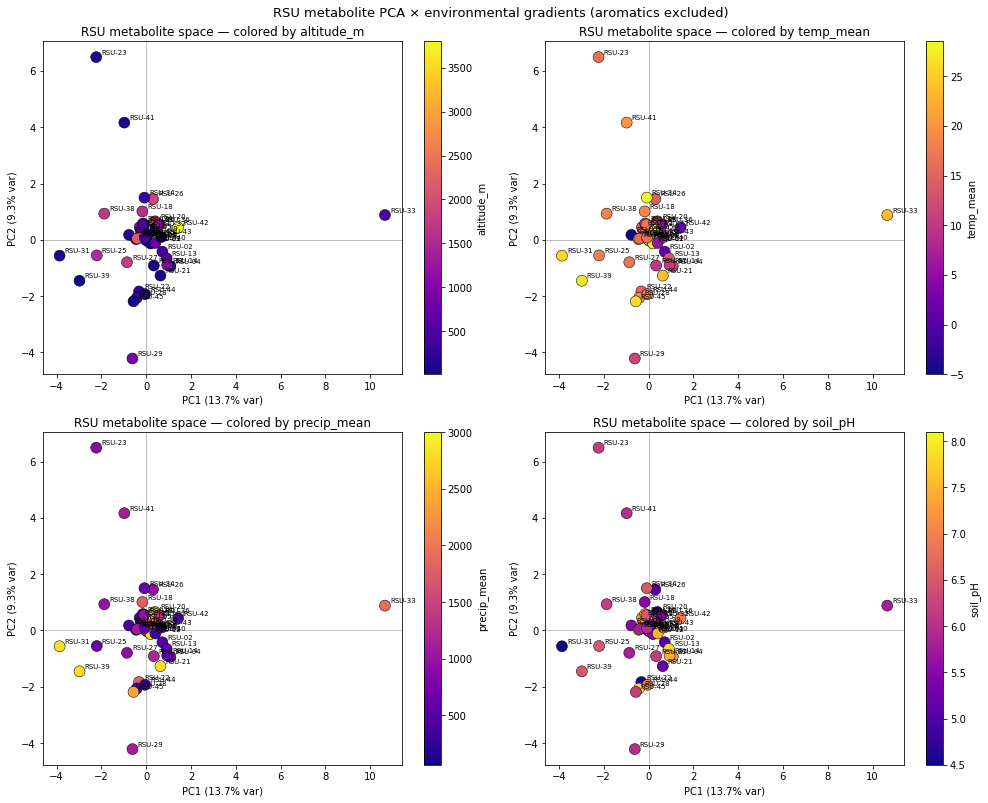


PC loadings:
                                                   PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9   PC10   PC11   PC12   PC13   PC14   PC15   PC16   PC17   PC18   PC19   PC20   PC21   PC22   PC23   PC24   PC25   PC26   PC27   PC28   PC29
organic_acids.lactic_acid                        0.028 -0.016  0.002 -0.015 -0.035 -0.014  0.654  0.264 -0.004 -0.005  0.001 -0.000 -0.003 -0.008 -0.003 -0.013 -0.017  0.282 -0.645 -0.058 -0.024 -0.017 -0.024  0.000 -0.011 -0.001 -0.002  0.000  0.000
organic_acids.citric_acid                       -0.029  0.106 -0.240  0.022 -0.070  0.415  0.138 -0.331 -0.212 -0.067 -0.170 -0.027  0.122 -0.151  0.140  0.365 -0.195 -0.302 -0.138 -0.148  0.035  0.033  0.281 -0.005 -0.007  0.320  0.019 -0.000  0.000
organic_acids.malic_acid                        -0.015 -0.349 -0.054  0.051  0.010 -0.369 -0.135  0.273 -0.158 -0.198  0.014  0.050  0.155 -0.060  0.110  0.378 -0.186 -0.205 -0.103 -0.149  0.434  0.002  0.019  0.044 -0.081 -0.292 -0.

In [6]:
rsu_met_valid = rsu_metabolites.dropna(how='all')
rsu_met_filled = rsu_met_valid.apply(lambda col: col.fillna(col.mean()))
# Drop columns that are still all-NaN after filling (no RSU has any data for them)
rsu_met_filled = rsu_met_filled.dropna(axis=1, how='all')

if len(rsu_met_valid) < 3:
    print(f"Only {len(rsu_met_valid)} RSUs with geo dim data — need more coverage for PCA.")
else:
    active_dims = list(rsu_met_filled.columns)
    print(f"RSUs in PCA: {len(rsu_met_valid)}")
    print(f"Active dims after dropping all-null columns: {len(active_dims)} of {len(geo_dims)}")

    scaler = StandardScaler()
    X = scaler.fit_transform(rsu_met_filled.values)
    pca = PCA(n_components=min(len(rsu_met_valid), len(active_dims)))
    scores = pca.fit_transform(X)

    print(f"Explained variance: {pca.explained_variance_ratio_.round(3)}")

    env_gradient_vars = ['altitude_m', 'temp_mean', 'precip_mean', 'soil_pH']
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    axes = axes.flatten()

    for ax, env_var in zip(axes, env_gradient_vars):
        color_vals = env_df.loc[rsu_met_valid.index, env_var]
        valid_mask = color_vals.notna()

        sc = ax.scatter(
            scores[valid_mask, 0], scores[valid_mask, 1],
            c=color_vals[valid_mask], cmap='plasma',
            s=120, zorder=3, edgecolors='k', linewidths=0.5
        )
        plt.colorbar(sc, ax=ax, label=env_var)

        for i, (rsu_id, score) in enumerate(zip(rsu_met_valid.index, scores)):
            ax.annotate(rsu_id, (score[0], score[1]),
                        textcoords='offset points', xytext=(5, 3), fontsize=7)

        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
        ax.set_title(f'RSU metabolite space — colored by {env_var}')
        ax.axhline(0, color='gray', lw=0.5)
        ax.axvline(0, color='gray', lw=0.5)

    plt.suptitle('RSU metabolite PCA × environmental gradients (aromatics excluded)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('../data/metabolites/rsu_pca_env_gradients.png', dpi=150, bbox_inches='tight')
    plt.show()

    loadings = pd.DataFrame(pca.components_.T, index=active_dims,
                            columns=[f'PC{i+1}' for i in range(pca.n_components_)])
    print("\nPC loadings:")
    print(loadings.round(3).to_string())

## Strongest env × metabolite signals

Which environmental features most strongly predict which metabolite dimensions?
Top correlations by absolute rho, filtered to pairs with sufficient data.

In [7]:
# Unstack correlation matrix and sort by |rho|
corr_long = corr_df.stack().reset_index()
corr_long.columns = ['env_feature', 'metabolite_dim', 'rho']
pval_long = pval_df.stack().reset_index()
pval_long.columns = ['env_feature', 'metabolite_dim', 'pval']
n_long = n_df.stack().reset_index()
n_long.columns = ['env_feature', 'metabolite_dim', 'n']

signals = corr_long.merge(pval_long).merge(n_long)
signals = signals.dropna(subset=['rho'])
signals['abs_rho'] = signals['rho'].abs()
signals = signals.sort_values('abs_rho', ascending=False)

print("Top env × metabolite correlations (Spearman rho, * = p < 0.1):")
print()
for _, row in signals.head(20).iterrows():
    star = '*' if row['pval'] < 0.1 else ' '
    print(f"  {star} rho={row['rho']:+.3f}  p={row['pval']:.3f}  n={int(row['n'])}  "
          f"{row['env_feature']}  →  {row['metabolite_dim']}")

Top env × metabolite correlations (Spearman rho, * = p < 0.1):

  * rho=+1.000  p=0.000  n=4  lat  →  key_flavor_bioactives.hydroxytyrosol
  * rho=+0.899  p=0.015  n=6  lat  →  primary_metabolites.fructose_concentration
  * rho=-0.841  p=0.036  n=6  industrial_processing  →  key_flavor_bioactives.conjugated_linoleic_acid
  * rho=+0.829  p=0.042  n=6  temp_seasonality  →  key_flavor_bioactives.conjugated_linoleic_acid
  * rho=+0.806  p=0.053  n=6  fermentation_prevalence  →  primary_metabolites.fructose_concentration
    rho=-0.800  p=0.104  n=5  lat  →  terpenes.linalool
    rho=-0.800  p=0.104  n=5  temp_seasonality  →  terpenes.linalool
    rho=+0.800  p=0.200  n=4  precip_mean  →  key_flavor_bioactives.hydroxytyrosol
    rho=-0.800  p=0.200  n=4  precip_seasonality  →  key_flavor_bioactives.hydroxytyrosol
  * rho=-0.790  p=0.011  n=9  industrial_processing  →  primary_metabolites.stearic_acid
  * rho=-0.771  p=0.072  n=6  temp_mean  →  key_flavor_bioactives.conjugated_linoleic_acid
